Loaded: (9850, 10)
   Unnamed: 0                 name  height  width  left  top  right  bottom  \
0           0  vehicle_0000001.jpg    1080   1920   597    3    935     341   
1           1  vehicle_0000002.jpg    1080   1920   399  283    875     874   
2           2  vehicle_0000003.jpg    1080   1920   597   97    970     538   
3           3  vehicle_0000004.jpg    1080   1920   671    5    978     308   
4           4  vehicle_0000005.jpg    1080   1920   502  341    927     844   

  category  nVehicles  
0      SUV          1  
1      SUV          1  
2      SUV          1  
3    Sedan          1  
4    Sedan          1  
Processing images...
Feature shape: (9850, 1764)

Running Cross-Validation...
CV Scores: [0.83045685 0.83553299 0.82335025 0.82436548 0.8248731 ]
Mean CV Accuracy: 0.8277157360406091
Std Dev: 0.004625699796911495

Cross-Validated Classification Report:
              precision    recall  f1-score   support

         Bus       0.86      0.81      0.84       555


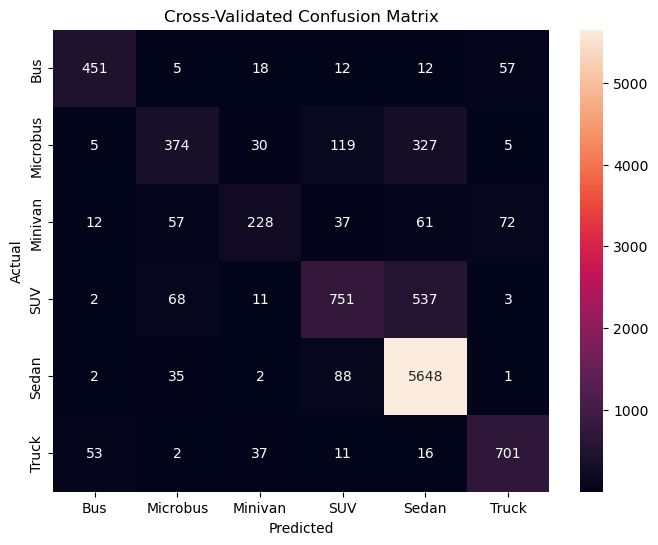


Training final model on train/test split...

Final Test Classification Report:
              precision    recall  f1-score   support

         Bus       0.84      0.83      0.83       111
    Microbus       0.79      0.49      0.60       172
     Minivan       0.82      0.53      0.64        93
         SUV       0.80      0.60      0.68       275
       Sedan       0.87      0.99      0.92      1155
       Truck       0.86      0.91      0.89       164

    accuracy                           0.85      1970
   macro avg       0.83      0.72      0.76      1970
weighted avg       0.85      0.85      0.84      1970



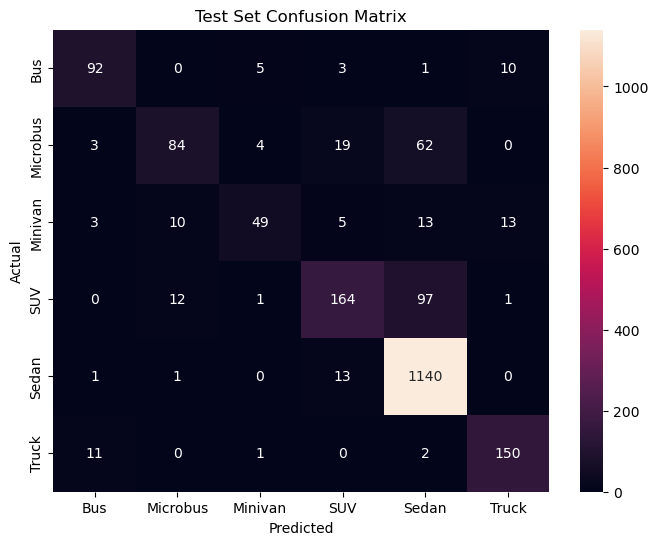

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# File paths
IMAGE_FOLDER = "C:/Users/clair/Downloads/BITVehicle"
CSV_FILE = "C:/Users/clair/Downloads/BITVehicle/VehicleInfo.csv"
IMG_SIZE = (64, 64)
TEST_SIZE = 0.2

# Load CSV
df = pd.read_csv(CSV_FILE)

print("Loaded:", df.shape)
print(df.head())

# Extract features
features = []
labels = []

print("Processing images...")

for _, row in df.iterrows():
    img_name = row["name"]
    label = row["category"]

    left = int(row["left"])
    top = int(row["top"])
    right = int(row["right"])
    bottom = int(row["bottom"])

    img_path = os.path.join(IMAGE_FOLDER, img_name)

    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    img = cv2.imread(img_path)

    if img is None:
        continue

    crop = img
    #[top:bottom, left:right]

    if crop.size == 0:
        continue

    crop = cv2.resize(crop, IMG_SIZE)
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features.append(hog_features)
    labels.append(label)

features = np.array(features)
labels = np.array(labels)

print("Feature shape:", features.shape)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nRunning Cross-Validation...")
cv_scores = cross_val_score(pipeline, features, y, cv=skf)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

# Cross-validated predictions for confusion matrix
y_pred_cv = cross_val_predict(pipeline, features, y, cv=skf)

print("\nCross-Validated Classification Report:")
print(classification_report(y, y_pred_cv, target_names=le.classes_))

cm_cv = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Cross-Validated Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    features, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=42
)

# Fit pipeline on training data
print("\nTraining final model on train/test split...")
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [1]:
import joblib

#joblib.dump(pipeline, "vehicle_svm_pipeline.pkl")
#joblib.dump(le, "vehicle_label_encoder.pkl")

joblib.dump(best_model, "vehicle_svm_pipeline1.pkl")
joblib.dump(le, "vehicle_label_encoder1.pkl")

NameError: name 'best_model' is not defined